# Monte Carlo Tree earch Attempt

This notebook shall hold all the attempts for MCTS.
Given a Pauli word with k Pauli strings $P_k$, a tree can be formed where each level is at least 1 Pauli string less: $P_k \,\to\, P_{k-1}\,\to\,P_{k-2}\dots$. Each node will have as many children as it has Pauli strings. This means the number of possible actions space for each node is k. However to get for example from the root node to the child associated with its first Pauli string has $n^{n-2}$ (direct) reductions, where n is the number of nonidentity in the first Pauli string. To find the best - where best is defined as the (direct) reduction that also reduces the number of nonidentities in the Pauli word the most - reduction you would also need to traverse a tree $P^{1_n}_{k} \,\to\, P^{1_1}_{k}$ (read as the reduction of the first Pauli string from n nonidentities to 1 nonidentity). Upon the Pauli string only having 1 nonidentity, it is implementable and will be pruned from the Pauli word, producing a $P^1_{k-1}$. Because there are so many possible reductions for just one Pauli string which have their own tree a method to solve this is also necessary. A strong suggestion has just been using a heuristic way to find a good solution.

_Concerns:_ 
1. Why even have reductions for specific Pauli strings? Would not a more efficient method be trying to solve multiple Pauli strings simultaneously? - This concern is valid and is an active question. However there are no clear methods so far to solve multiple stringswhich are not greedy except A* (worth revisiting even though admissiblility of heuristic would be unanswerable).  
2. Would not this way be unscalable with size? This remains to be seen in experiments. 

## Initial Variables, Libraries and Classes 

In [1]:
import random as rnd
import networkx as nx
from networkx.drawing.nx_agraph import write_dot, graphviz_layout
import matplotlib.pyplot as plt
import numpy as np
import math
import time

In [2]:
# important global variables
timeout = 10
PARAM = math.sqrt(2)

In [3]:
# class that implements tableau and necessary operations
# References -Improved Simulation of Stabilizer Circuits by Scott Aaronson & Daniel Gottesman
# - Google Tableau implementation
class Cirq_Tableau:
    
    def __init__(
        self,
        pauli_word: list[str] = None  
    ):
        if pauli_word is None or len(pauli_word) == 0:
            self._column_num = None
            self._row_num = None

            self._ss, self._xs, self._zs = None, None, None
        else:
            if "-" in pauli_word[0]:
                self._column_num = len(pauli_word[0][1:]) 
            else:
                self._column_num = len(pauli_word[0])
            self._row_num = len(pauli_word)

            self._ss = self.create_sign(pauli_word)
            self._xs, self._zs = self.create_tab(pauli_word)

    # setters & getters 
    @property
    def ss(self) -> np.ndarray:
        return self._ss

    @ss.setter 
    def ss(self, new_ss: np.ndarray):
        self._ss = new_ss
        
    @property
    def xs(self) -> np.ndarray:
        return self._xs

    @xs.setter 
    def xs(self, new_xs: np.ndarray):
        self._xs = new_xs
        
    @property
    def zs(self) -> np.ndarray:
        return self._zs

    @zs.setter 
    def zs(self, new_zs: np.ndarray):
        self._zs = new_zs
        
    @property
    def column_num(self) -> int:
        return self._column_num

    @column_num.setter 
    def column_num(self, new_num: int):
        self._column_num = new_num
    
    @property
    def row_num(self) -> int:
        return self._row_num

    @row_num.setter 
    def row_num(self, new_num: int):
        self._row_num = new_num

    # functions that create parts of tableau
    def create_sign(self, pauli_word: list[str]):
        temp_ss = np.zeros((self.row_num), dtype=int)
        for pauli_string in pauli_word:
            if "-" in pauli_string:
                index = pauli_word.index(pauli_string)
                pauli_word[index] = pauli_string.replace("-", "")
                #print(pauli_word)
                temp_ss[index] = 1
        return temp_ss
        
    def create_tab(self, pauli_word: list[str]):
        temp_x = np.zeros((self.row_num, self.column_num), dtype=int)
        temp_z = np.zeros((self.row_num, self.column_num), dtype=int)
        for i, pauli_string in enumerate(pauli_word):
            for j, pauli in enumerate(pauli_string):
                if pauli == "X" or pauli == "Y":
                    temp_x[i][j] = 1
                if pauli == "Z" or pauli == "Y":
                    temp_z[i][j] = 1
        return temp_x, temp_z

    # Clifford operations on tableau. 
    def apply_H(self,column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.xs[:, column], self.zs[:, column] = self.zs[:, column].copy(), self.xs[:, column].copy()

    def apply_S(self, column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.zs[:, column] = self.xs[:, column] ^ self.zs[:, column]

    def apply_CX(self, control: int, target: int):
        self.ss ^= (
            (self.xs[:, control] & self.zs[:, target])
            &(~(self.xs[:, target] ^ self.zs[:, control]))
        )
        self.xs[:, target] ^= self.xs[:, control]
        self.zs[:, control] ^= self.zs[:, target]

    # class operations necessary for comparisons and equating
    def copy(self):
        new_tab = Cirq_Tableau()
        new_tab.column_num = self.column_num
        new_tab.row_num = self.row_num
        new_tab.ss = self.ss.copy()
        new_tab.zs = self.zs.copy()
        new_tab.xs = self.xs.copy()
        return new_tab
    
    def __eq__(self, other):
        if not isinstance(other, type(self)):
            return NotImplemented  
        return (
            self.column_num == other.column_num
            and self.row_num == other.row_num
            and np.array_equal(self.ss, other.ss)
            and np.array_equal(self.xs, other.xs)
            and np.array_equal(self.zs, other.zs)
        )
    
    def return_string(self):
        string = ''
        for i in range(self.row_num):
            if self.ss[i]:
                string += "-"  

            for j in range(self.column_num):
                if self.xs[i][j] and not self.zs[i][j]:
                    string += "X"
                elif not self.xs[i][j] and self.zs[i][j]:
                    string += "Z"
                elif self.xs[i][j] and self.zs[i][j]:
                    string += "Y"
                else:
                    string += "I"
            if i < self.row_num - 1:
                string += "\n" 

        return string
    
    def __copy__(self):
        return self.copy()
        

    def __str__(self) -> str:
        ss = np.expand_dims(self.ss, axis = 1)
        xz = np.concatenate((self.xs, self.zs, ss), axis=1)
        return str(xz)

    def __hash__(self) -> int:
        return hash(self.zs.tobytes() + self.xs.tobytes() + self.ss.tobytes())

    def __lt__(self, other):
        return self.row_num < other.row_num

## Heuristic method to solve single Pauli string

To move from $P_k \,\to\, P^\alpha_{k-1}$, where $\alpha$ is the number describing the index of the Pauli string we are reducing, we need a way a to make it deterministic.  Having multiple reductions that fulfil $P_k \,\to\, P^\alpha_{k-1}$ means that there is no deterministic way to get to the child. So a heuristic way to construct this solution has been suggested 

In [4]:
# TODO: write a more efficient pruning algorithm
def prune(tableau: Cirq_Tableau):
    '''
    Function to remove rows in a tableau with only a single nonidentity operation
    
    :param tableau: Cirq_Tableau to act on
    '''
    prn_ndxs = [] # list to hold all row indices to be pruned
    
    tab = tableau.copy() # copy of tableau to work on

    single_q = [] # loist of single qubit operations 
    
    # extracts x, z and sign arrays
    x, z, s = tab.xs, tab.zs, tab.ss

    # bitwise ORs x and z arrays in tableau to create array where nonidentity operation indices have 1 in them
    weight_array = x | z

    # loop that checks through each row to find out if it has a Pauli weight of 1
    for r_ndx in range(len(weight_array)):
        if sum(weight_array[r_ndx])  == 1:

            # appends index to be pruned if Pauli weight == 1
            prn_ndxs.append(r_ndx)

            # checks what type of Pauli is on that index X, Y or Z and appends to path with action weight of zero 
            if sum(z[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("X", int(np.argmax(x[r_ndx] == 1))))
                else:
                    single_q.append(("-X", int(np.argmax(x[r_ndx] == 1))))
            elif sum(x[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("Z", int(np.argmax(z[r_ndx] == 1))))
                else:
                    single_q.append(("-Z", int(np.argmax(z[r_ndx] == 1))))
            else:
                if s[r_ndx] == 0:
                    single_q.append(("Y", int(np.argmax(x[r_ndx] == 1))))
                else:
                    single_q.append(("-Y", int(np.argmax(x[r_ndx] == 1))))
                    
        elif sum(weight_array[r_ndx])  == 0: # elif removes fully I lines 
            x, z, s = np.delete(x, r_ndx, axis=0), np.delete(z, r_ndx, axis=0), np.delete(s, r_ndx)
            
    # prunes rows 
    x, z, s = np.delete(x, prn_ndxs, axis=0), np.delete(z, prn_ndxs, axis=0), np.delete(s, prn_ndxs)
    column_num = len(x[0]) if x.size != 0 else 0 
    row_num = len(x)

    # updates tableau and returns it 
    tab.xs, tab.zs, tab.ss, tab.column_num, tab.row_num = x, z, s, column_num,row_num
    return tab, single_q
    

The next three cells are used to construct the heuristic. The heuristic is broken down into three functions for readability purposes. I am sure there is a more efficient way to construct this idea or even a better heuristic generally but for now this will do

Definitions:

Reducible Pair: any one of four pairs of Paulis wich 'reduce' when a CX ois applied to them .e.g. XX becomes XI 

Allowed Transformations: a combination of S, H, I that can transform a pair of Paulis into a reducible pair

In [5]:
def identify(tableau, op_list, ctrl, targ):
    '''
    Function to identify the best operation amongst a list 
    This function is mainly used to identify which one of the allowed transformations for a pair produces the best benefit

    tableau: Cirq_Tableau that holds our Pauli word
    op_list: list of action tuples which are possible operations
    ctrl: int that is index of control qubit
    targ: int that is index of target qubit
    '''
    operation = None # best operation
    benefit = -float('inf') # benefit of an operation benefit = reduce - increase 
    reduced = 0 # number of reducible pairs across the ctrl and targ (equivalent to how many single qubit operations will be removed)
    increased = 0 # number of increasing pairs across the ctrl and targ (equivalent to how many single qubit operations will be added)

    # loop to run through possible operations 
    for op in op_list:
        
        tab = tableau.copy()

        # loop to go over all the gates in the operation and apply them accordingly
        for act in op:
            match act[0]:
                case "H":
                    tab.apply_H(act[1])
                case "S":
                    tab.apply_S(act[1])

        # calculation of reduced and increased for this particular action
        reduce = sum((tab.xs[:, ctrl] & tab.xs[:, targ] & ~tab.zs[:, targ]) | (~tab.xs[:, ctrl] & tab.zs[:, ctrl] & tab.zs[:, targ]))
        increase = sum((~tab.xs[:, ctrl] & ~tab.zs[:, ctrl] & tab.zs[:, targ]) | (tab.xs[:, ctrl] & ~tab.xs[:, targ] & ~tab.zs[:, targ]))
        
        # condition to calculate better benefit and replace necessary values
        # benefit is the total no. of reducible pairs minus total no. of increasing pairs
        # this will total how many single qubits will be removed from the entire Pauli word
        if reduce - increase > benefit:
            benefit = reduce - increase
            operation = op
            reduced = reduce
            increased = increased
        elif reduce - increase == benefit:
            if reduce > reduced:
                benefit = reduce - increase
                operation = op
                reduced = reduce
                increased = increase

    # appending CX to the operation to complete it
    operation.append(("CX", ctrl, targ))
    return reduced, increased, operation 

In [6]:
def compare(tab, ndx, ctrl, targ):
    '''
    Function that takes in a pair and identifies what Paulis are in it

    tab: Cirq_tableau holding Pauli word
    ndx: int holding index (row) of the Pauli string currently being reduced
    ctrl: int holding index (column) of control qubit
    targ: int holding index (column) of target qubit
    '''

    if tab.xs[ndx][ctrl] & ~tab.zs[ndx][ctrl]: # if control is X
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for XX
            op_list = [[], [("S", ctrl)], [("H", ctrl), ("H", targ)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for XY
            op_list = [[("S", ctrl), ("S", targ)], [("S", targ)], [("H", ctrl)],
                      [("H", ctrl), ("H", targ)]]
            return identify(tab, op_list, ctrl, targ)

        else:# if target is Z

            # list of allowed transformations for XZ
            op_list = [[("S", ctrl), ("H", targ)], [("H", targ)], [("H", ctrl)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
    elif tab.xs[ndx][ctrl] & tab.zs[ndx][ctrl]: # if control is Y
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for YX
            op_list = [[], [("S", ctrl)], [("H", ctrl)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for YY
            op_list = [[("S", ctrl), ("S", targ)], [("H", ctrl),("S", targ)],
                      [("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

        else:# if target is Z

            # list of allowed transformations for YZ
            op_list = [[("H", targ)], [("S", ctrl), ("H", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
    else: # if control is Z
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for ZX
            op_list = [[("H", targ)], [("H", ctrl)], [("S", ctrl),("H", targ)],
                      [("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for ZY
            op_list = [[], [("S", ctrl)], [("H", targ)], [("S", ctrl),("H", targ)], [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

        else:# if target is Z

            # list of allowed transformations for ZZ
            op_list = [[], [("H", ctrl), ("H", targ)], [("S", ctrl)], [("S", targ)], [("S", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

In [7]:
def heuristic(tableau, ndx):
    '''
    Heuristic function to produce a single reduction from one node of a tree to a child

    tableau: Cirq_Tableau holding Pauli word
    ndx: int holding index (row) of current Pauli string being reduced
    '''
    tab = tableau.copy()
    reduction = [] # reduction of Pauli string

    # loop to run until break condition is met - Pauli string is implementable
    while True:
        operation = None
        benefit = -float('inf')
        reduced = 0
        increased = 0

        # break condition 
        if sum(tab.xs[ndx] | tab.zs[ndx]) == 1:
            break
            
        #  loop to cycle over all qubit indexes to get all combinations of control and target 
        for i in range(tab.column_num):
            if i != tab.column_num -1 and (tab.xs[ndx][i] or tab.zs[ndx][i]): # prevents I's 
                for j in range(i+1, tab.column_num):
                    if tab.xs[ndx][j] or tab.zs[ndx][j]: # prevents I's 

                        # conditions to check for better benefit with i as ctrl and j as targ
                        reduce, increase, op = compare(tab, ndx, i, j)
                        if (reduce - increase) > benefit:
                            benefit = reduce - increase
                            operation = op
                            reduced = reduce
                            increased = increase
                        elif (reduce - increase) == benefit:
                            if reduce > reduced:
                                operation = op
                                reduced = reduce
                                increased = increase
                                
                        # conditions to check for better benefit with j as ctrl and i as targ
                        reduce, increase, op = compare(tab, ndx, j, i)
                        if (reduce - increase) > benefit:
                            benefit = reduce - increase
                            operation = op
                            reduced = reduce
                            increased = increase
                        elif (reduce - increase) == benefit:
                            if reduce > reduced:
                                operation = op
                                reduced = reduce
                                increased = increase

        # condition that picks the best operation and applies it
        if operation != None:
            for action in operation:
                match action[0]:
                    case "CX":
                        tab.apply_CX(action[1], action[2])
                    case "S":
                        tab.apply_S(action[1])
                    case "H":
                        tab.apply_H(action[1])
                        
            reduction += operation # appends to reduction

    # prunes of implemented Pauli string
    tab, single_q = prune(tab)
    reduction += single_q # appends to reduction
    
    return tab, reduction

## Monte Carlo Tree Search Implementation

In [8]:
# class to hold node information for tree 
class Node:

    def __init__(
        self,
        state
    ):
        self._ni = 0 # number of simulations 
        self._curr_cx_num = 0 # number of CXs that were needed to get to current node
        self._qi = 0 # cumulative CXs for root to terminal node across simulations
        self._parent = None # node that had action applied to get to current node
        self._action = None # action applied to parent node to get to current node
        self._children = [] # nodes produced when actions are applied to current node
        self._state = state # Pauli word representing state of node
        
    # properties and setters 
    @property
    def ni(self) -> int:
        return self._ni

    @ni.setter
    def ni(self, new_ni: int):
        self._ni = new_ni

    @property
    def qi(self) -> int:
        return self._qi

    @qi.setter
    def qi(self, new_num: int):
        self._qi = new_num
        
    @property
    def curr_cx_num(self) -> int:
        return self._curr_cx_num

    @curr_cx_num.setter
    def curr_cx_num(self, new_num: int):
        self._curr_cx_num = new_num
        
    @property
    def state(self):
        return self._state

    @state.setter
    def state(self, new_word):
        self._state = new_word

    @property
    def parent(self):
        return self._parent

    @parent.setter
    def parent(self, new_parent):
        self._parent = new_parent

    @property
    def action(self):
        return self._action

    @action.setter
    def action(self, new_action):
        self._action = new_action
        
    @property
    def children(self):
        return self._children

    @children.setter
    def children(self, new_children):
        self._children = new_children

   
    # standard necessary functions    
    def __hash__(self) -> int:
        return hash(self.parent) + hash(str(self.action))

    # useful specific fucntions
    def UCT(self, param):
        
        # if it has been completely unexplored 
        if self.ni == 0:
            return float('inf')

        # if it is a root (may never be used but just in case)
        if self.parent == None:
            # negative cx_num leads to larger values for smaller qi
            return -(self.qi/ self.ni)


        return -(self.qi/self.ni) + (param * math.sqrt(math.log(self.parent.ni)/ self.ni)) 

In [9]:
def cx_count(action_list):
    '''
    Function to count number of CXs present

    action_list: List containing information on gates applied 
    '''
    count = 0
    for action in action_list:
        if action[0] == "CX":
            count += 1

    return count

The next 5 cells describe the 4 steps of MCTS:

1. Selection - choosing the action that produces the best value
2. Expansion - connecting the new node produced by taking the action to the tree
3. Simulation (rollout) - running a simulation policy until you reach a terminal state and use its value as an approximation for the value of the new state
4. Backpropagation - taking the value at the terminal state and sending it back up to the root of the tree

In [10]:
def expand(node, function, graph):
    '''
    Function to expand out children of a leaf node

    node: selected node to expand out
    function: heuristic function to produce action
    '''
    
    # loop to create action for each possible child
    for i in range(node.state.row_num):
        new_state, new_action = function(node.state, i)
        graph.add_edge(f"[{node.state.return_string()}]", f"[{new_state.return_string()}]")
        new_node = Node(new_state)
        new_node.action = new_action
        new_node.parent = node
        new_node.curr_cx_num = node.curr_cx_num + cx_count(new_action)
        node.children.append(new_node)

In [11]:
def select(node, parameter):
    value = -float('inf')
    selected_node = None 

    # loop to go over all the child nodes and pick the one with the highest UCT
    for child in node.children:
        new_val = child.UCT(parameter)
        #print(new_val)
        if new_val > value:
            value = new_val
            #print(value)
            selected_node = child

    return selected_node

In [12]:
def tree_policy(node, function, parameter, tree):
    '''
    Function that runs through selections and expansions until it arrives at a leaf (unexpanded) node

    node: selected node to expand out
    function: heuristic function to prduce action
    parameter: float to hold paramter for UCT calculations
    '''

    # loop to keep selecting and expanding
    while True:

        # if it has no children - leaf node
        if not node.children:

            # if node has been visited or is a root node
            if node.ni != 0 or node.parent == None:
                if node.state.row_num == 0:
                    return node
                    
                expand(node, function, tree)
                node = select(node, parameter)
            else:
                return node
        else:
            node = select(node, parameter) # select one of the children

In [13]:
def rollout_policy(node, function):
    '''
    Function to simulate continuation of tree until a terminal node

    node: node to simulate from
    function: heuristic function to produce action between nodes
    '''
    state = node.state
    cx_num = node.curr_cx_num

    # loop to run until terminal node is found
    while True:

        # break condition
        if state.row_num == 0:
            return cx_num
            
        weight_word = state.xs | state.zs
        weight = -float('inf')
        index = None

        # loop to find Pauli string in current Pauli word with highest Pauli weight
        for i, string in enumerate(weight_word):
            w_sum = sum(string)
            if w_sum > weight:
                weight = w_sum 
                index = i

        state, actions = function(state, index)
        cx_num += cx_count(actions)
        

In [14]:
def backpropagate(node, value):
    '''
    Function to backpropagate estimated value at terminal state up through tree

    node: current node to backpropagate from
    value: value at terminal state
    '''

    # loop to backpropagate upwards until root is found
    while node != None:

        node.qi += value 
        node.ni += 1
        node = node.parent

In [15]:
def best_action(root_node):
    '''
    Function to acquire the best action to take based on average cx count across simulations
    '''
    path = None 
    num = float('inf')
    node = None

    # loop to go through alll child nodes and pick the one with lowest cx count
    for child in root_node.children:
        if child.qi != 0:
            if (child.qi/child.ni) < num:
                num = (child.qi/child.ni)
                path = child.action
                node = child
            elif (child.qi/child.ni) == num and child.ni > node.ni:
                num = (child.qi/child.ni)
                path = child.action
                node = child

    return path, node.state

In [53]:
def MCTS(root_node, function, param):
    '''
    Function that completely executes MCTS
    root_node: node that holds root node
    '''
    start_time = time.time() 
    current_time = time.time()
    tree_graph = nx.DiGraph()# graph to store tree produced in MCTS
    
    # loop to run specificed number of iterations
    while current_time < start_time + timeout:
        leaf_node = tree_policy(root_node, function, param, tree_graph) # selection and expansion phases 
        value = rollout_policy(leaf_node, function) # simulation of leaf node
        backpropagate(leaf_node, value)
        current_time = time.time()
        
    return best_action(root_node), tree_graph

In [60]:
def grapher(graph):
    '''
    Simple function to graph out tree produced in MCTS - need to improve

    graph: directed graph that represents the tree produced by MCTS
    '''
    plt.figure(figsize=(35, 30))
    nx.nx_agraph.write_dot(graph,'test.dot')
    pos =graphviz_layout(graph, prog='dot')
    nx.draw(tree, pos,  with_labels = True, node_color="white", node_size=3500)

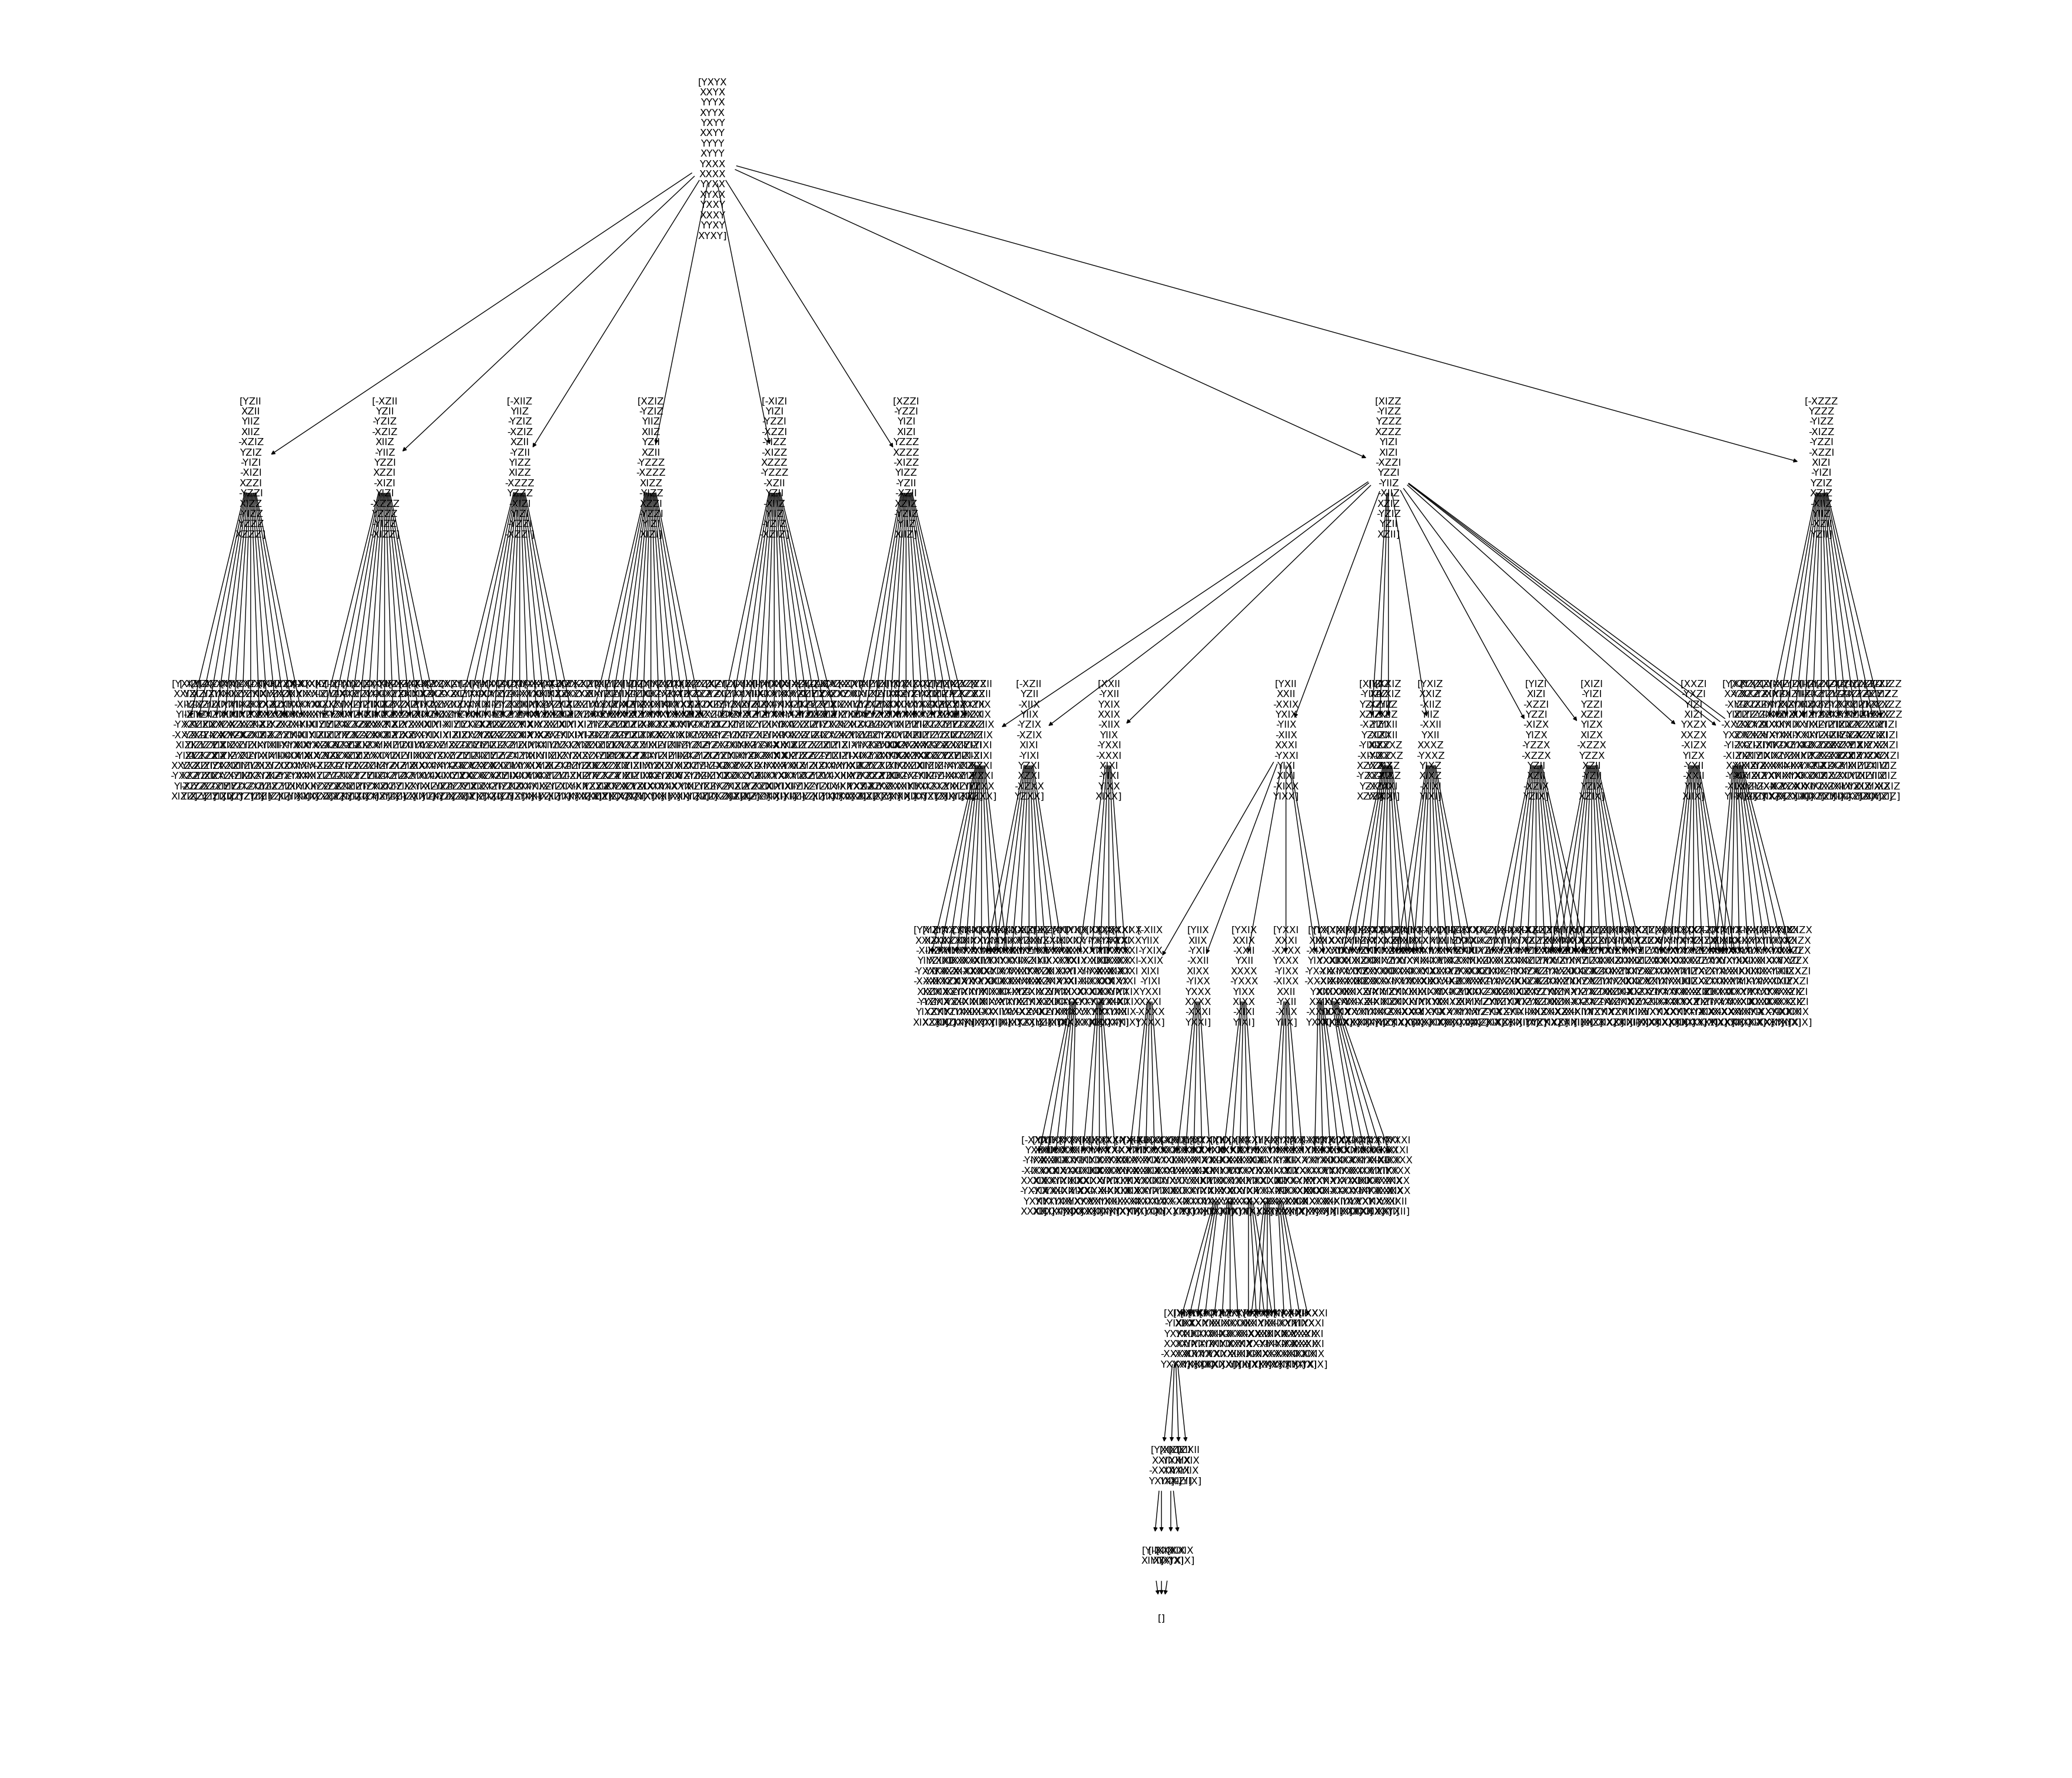

In [59]:
word =  [
        "YXYX",
        "XXYX",
        "YYYX",
        "XYYX",
        "YXYY",
        "XXYY",
        "YYYY",
        "XYYY",
        "YXXX",
        "XXXX",
        "YYXX",
        "XYXX",
        "YXXY",
        "XXXY",
        "YYXY",
        "XYXY"
    ]

example = Node(Cirq_Tableau(word))

action, tree = MCTS(example, heuristic, PARAM)
grapher(tree)

In [ ]:
def full_path(p_word, function, param):
    path = []
    while len(p_word.xs) != 0:
        action, new_word, graph = MCTS(Node(p_word), function, param)
        path += action
        p_word = new_word
        

    return path

## *Tests*